In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [2]:
file_path = "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/data/raw/loan.csv"

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset Shape:", df.shape)

Dataset Shape: (2260668, 145)


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.00,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.00,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.00,Apr-2001,1.00,NaN,45.00,9.00,1.00,4341,10.30,34.00,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.00,0.00,0.00,Feb-2019,84.92,Mar-2019,Feb-2019,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,0.00,16901.00,2.00,2.00,1.00,2.00,2.00,12560.00,69.00,2.00,7.00,2137.00,28.00,42000.00,1.00,11.00,2.00,9.00,1878.00,34360.00,5.90,0.00,0.00,140.00,212.00,1.00,1.00,0.00,1.00,NaN,2.00,NaN,0.00,2.00,5.00,3.00,3.00,16.00,7.00,18.00,5.00,9.00,0.00,0.00,0.00,3.00,100.00,0.00,1.00,0.00,60124.00,16901.00,36500.00,18124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.00,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.00,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.00,Jun-1987,0.00,71.00,75.00,13.00,1.00,12315,24.20,44.00,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.00,0.00,0.00,Feb-2019,777.23,Mar-2019,Feb-2019,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,1208.00,321915.00,4.00,4.00,2.00,3.00,3.00,87153.00,88.00,4.00,5.00,998.00,57.00,50800.00,2.00,15.00,2.00,10.00,24763.00,13761.00,8.30,0.00,0.00,163.00,378.00,4.00,3.00,3.00,4.00,NaN,4.00,NaN,0.00,2.00,4.00,4.00,9.00,27.00,8.00,14.00,4.00,13.00,0.00,0.00,0.00,6.00,95.00,0.00,1.00,0.00,372872.00,99468.00,15000.00,94072.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.00,36 mo

In [4]:
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
893305,NaN,NaN,35000,35000,35000.00,36 months,19.99,1300.55,D,D4,VP,5 years,RENT,106000.00,Source Verified,Nov-2016,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,450xx,OH,25.55,0.00,Feb-2001,1.00,NaN,NaN,13.00,0.00,33553,79.70,35.00,f,10786.60,10786.60,35037.11,35037.11,24213.40,10823.71,0.00,0.00,0.00,Feb-2019,1300.55,Mar-2019,Feb-2019,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,0.00,57858.00,1.00,5.00,0.00,3.00,14.00,24305.00,44.00,1.00,3.00,12296.00,59.00,42100.00,2.00,2.00,1.00,6.00,4451.00,0.00,100.50,0.00,0.00,72.00,188.00,4.00,4.00,1.00,17.00,NaN,4.00,NaN,0.00,5.00,5.00,5.00,16.00,8.00,8.00,26.00,5.00,13.00,0.00,0.00,0.00,1.00,100.00,100.00,0.00,0.00,97654.00,57858.00,33400.00,55554.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1512136,NaN,NaN,4200,4200,4200.00,36 months,9.44,134.43,B,B1,GS-09 IT Security Specialist,3 years,MORTGAGE,105355.00,Not Verified,Aug-2017,Fully Paid,n,NaN,NaN,home_improvement,Home improvement,808xx,CO,19.34,0.00,Dec-1998,0.00,NaN,NaN,11.00,0.00,32142,88.50,38.00,f,0.00,0.00,4251.26,4251.26,4200.00,51.26,0.00,0.00,0.00,Sep-2017,4253.46,NaN,Jun-2018,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,0.00,531400.00,1.00,6.00,2.00,8.00,11.00,99724.00,92.00,1.00,1.00,18116.00,91.00,36300.00,0.00,10.00,2.00,10.00,48309.00,0.00,100.70,0.00,0.00,153.00,224.00,3.00,3.00,4.00,81.00,NaN,9.00,NaN,0.00,2.00,4.00,2.00,2.00,25.00,4.00,9.00,4.00,11.00,0.00,0.00,0.00,4.00,100.00,100.00,0.00,0.00,552784.00,131866.00,31500.00,113899.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
823685

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 2.4 GB


Generating the Audit Table

In [6]:
audit_df = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'missing_count': df.isnull().sum().values,
    'missing_percent': (
        df.isnull().sum().values / len(df)
    ) * 100,
    'unique_values': [df[col].nunique() for col in df.columns]
})

audit_df.sort_values(
    by='missing_percent',
    ascending=False
).head(50)

,column,dtype,missing_count,missing_percent,unique_values
0,id,float64,2260668,100.00,0
1,member_id,float64,2260668,100.00,0
18,url,float64,2260668,100.00,0
134,orig_projected_additional_accrued_interest,float64,2252242,99.63,7313
127,hardship_amount,float64,2250055,99.53,8950
132,hardship_dpd,float64,2250055,99.53,34
133,hardship_loan_status,str,2250055,99.53,5
126,deferral_term,float64,2250055,99.53,1
129,hardship_end_date,str,2250055,99.53,27
125,hardship_status,str,2250055,99.53,3


Saving the Audit Table

In [8]:
audit_df.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/outputs/metrics/initial_data_audit.csv",
    index=False
)

In [9]:
df['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

Reducing the size by removing entires outside the scope of the problem.

In [10]:
target_status = [
    'Fully Paid',
    'Charged Off'
]

df = df[df['loan_status'].isin(target_status)]

print(df['loan_status'].value_counts())
print(df.shape)

loan_status
Fully Paid     1041952
Charged Off     261655
Name: count, dtype: int64
(1303607, 145)


In [13]:
df['target_default'] = np.where(
    df['loan_status'] == 'Charged Off',
    1,
    0
)

df[['loan_status', 'target_default']].head()

,loan_status,target_default
100,Fully Paid,0
152,Fully Paid,0
170,Fully Paid,0
186,Fully Paid,0
215,Fully Paid,0


In [14]:
df['target_default'].value_counts(normalize=True) * 100

target_default
0   79.93
1   20.07
Name: proportion, dtype: float64

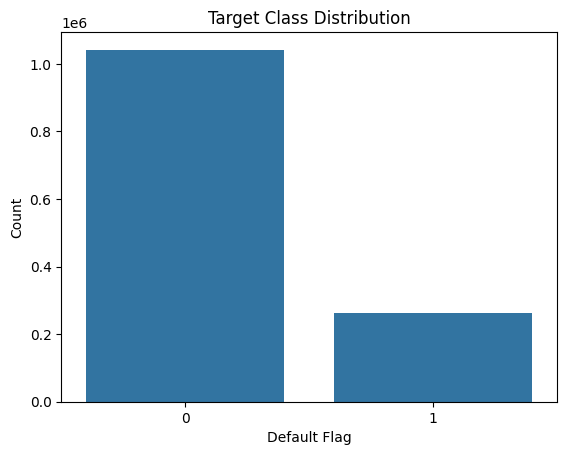

In [15]:
sns.countplot(x='target_default', data=df)

plt.title('Target Class Distribution')
plt.xlabel('Default Flag')
plt.ylabel('Count')

plt.show()

Removing columns which are not suitable for prediction. Columns which reveal post-loan outcomes are removed.

In [16]:
leakage_columns = [
    'collection_recovery_fee',
    'recoveries',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'last_pymnt_amnt',
    'last_pymnt_d',
    'next_pymnt_d',
    'total_pymnt',
    'total_pymnt_inv',
    'out_prncp',
    'out_prncp_inv'
]

existing_leakage_cols = [
    col for col in leakage_columns
    if col in df.columns
]

existing_leakage_cols

['collection_recovery_fee',
 'recoveries',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'last_pymnt_amnt',
 'last_pymnt_d',
 'next_pymnt_d',
 'total_pymnt',
 'total_pymnt_inv',
 'out_prncp',
 'out_prncp_inv']

In [17]:
df = df.drop(columns=existing_leakage_cols)

print(df.shape)

(1303607, 134)


Missing Values Visualization

In [18]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent.head(30)

id                                           100.00
member_id                                    100.00
url                                          100.00
orig_projected_additional_accrued_interest    99.74
hardship_last_payment_amount                  99.59
hardship_length                               99.59
payment_plan_start_date                       99.59
hardship_dpd                                  99.59
hardship_payoff_balance_amount                99.59
hardship_loan_status                          99.59
hardship_reason                               99.59
hardship_status                               99.59
hardship_amount                               99.59
deferral_term                                 99.59
hardship_type                                 99.59
hardship_end_date                             99.59
hardship_start_date                           99.59
sec_app_mths_since_last_major_derog           99.54
sec_app_revol_util                            98.76
revol_bal_jo

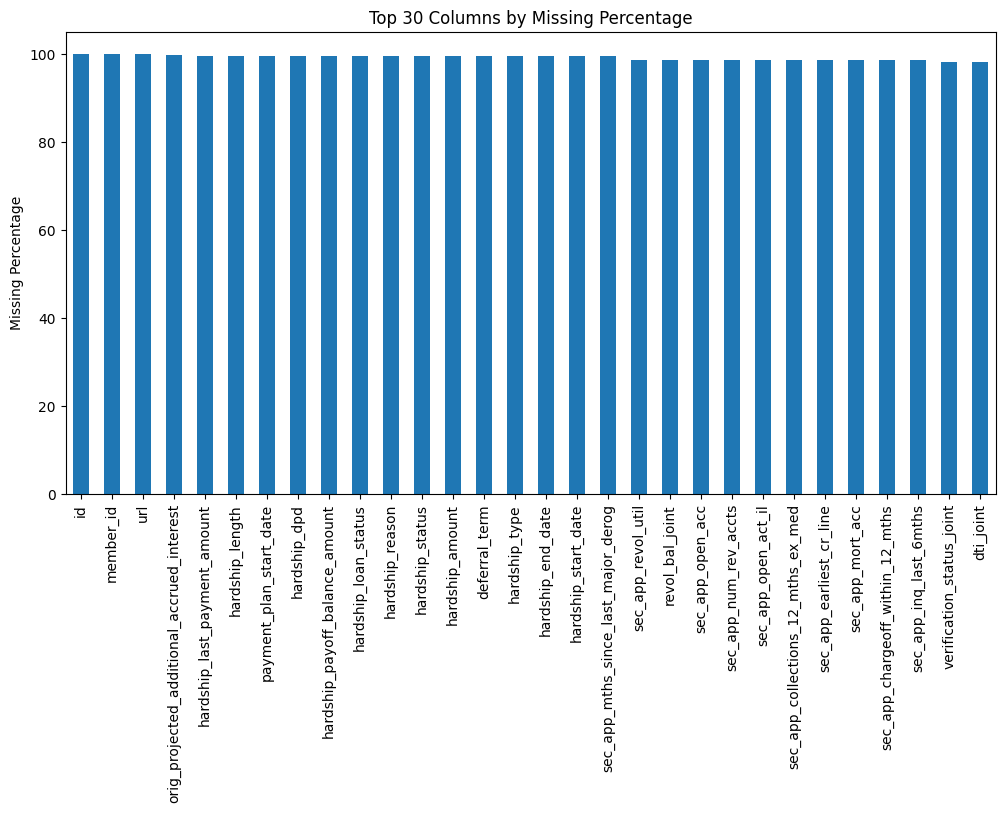

In [19]:
plt.figure(figsize=(12,6))

missing_percent.head(30).plot(kind='bar')

plt.title('Top 30 Columns by Missing Percentage')
plt.ylabel('Missing Percentage')

plt.show()

In [20]:
print("Final Dataset Shape:", df.shape)

print("\nTarget Distribution:")
print(df['target_default'].value_counts())

print("\nMissing Values > 30%:")
print(
    missing_percent[missing_percent > 30]
)

Final Dataset Shape: (1303607, 134)

Target Distribution:
target_default
0    1041952
1     261655
Name: count, dtype: int64

Missing Values > 30%:
id                                           100.00
member_id                                    100.00
url                                          100.00
orig_projected_additional_accrued_interest    99.74
hardship_last_payment_amount                  99.59
hardship_length                               99.59
payment_plan_start_date                       99.59
hardship_dpd                                  99.59
hardship_payoff_balance_amount                99.59
hardship_loan_status                          99.59
hardship_reason                               99.59
hardship_status                               99.59
hardship_amount                               99.59
deferral_term                                 99.59
hardship_type                                 99.59
hardship_end_date                             99.59
hardship_start_date 

In [ ]:
df.to_csv(
    "/run/media/aditya-anurag/New Volume/Self/Personal/Project/Credit Risk Intelligence & Default Prediction/data/processed/audited_loan_data.csv",
    index=False
)